# TensorBinding.jl — Miscellaneous Capabilities

Specialised methods not covered in the core notebooks:

1. **Krylov Green's function** — warm-started DMRG-Krylov solve for $G^R(\omega)$
2. **Bernal bilayer graphene** — exact AB-stacked interlayer coupling
3. **SSH Krylov DoS** — Green's function in the topological gap


In [2]:
using LinearAlgebra
using Statistics
using Printf
using Plots
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl")
using .TensorBinding

---
## 1. Krylov Green's function with KPM warm start

`get_green_krylov` solves the vectorised linear system
$(\omega + i\eta - H)|G\rangle\rangle = |I\rangle\rangle$
using DMRG-like Krylov sweeps.  A low-order KPM Green's function serves
as the initial guess, dramatically reducing the sweep count.

---
## 1. AAH Hamiltonian — localized phase

$$H = -t \sum_{\langle i,j\rangle} c_i^\dagger c_j
       + V \sum_i \cos(2\pi b\,i + \phi)\,n_i,
\qquad b = \tfrac{1+\sqrt{5}}{2}$$

All eigenstates are exponentially localized for $V > 2t$.  We use $V = 3$,
$t = 1$ — well inside the localized phase.  The spectrum lies in
$[-2t-V,\, 2t+V] = [-5,\,5]$; we set `scale` analytically to avoid DMRG.

In [5]:
L_aah     = 20
t_aah     = 1.0
V_aah     = 3.0      # > 2t → strongly localized
phi_aah   = 0.0
scale_aah = (2t_aah + V_aah) * 1.1   # analytic bound × 10 % buffer

H_aah = TensorBinding.get_Hamiltonian("aah", (V=V_aah, phi=phi_aah, t=t_aah);
            L=L_aah, scale=scale_aah)
println(H_aah)

TBHamiltonian | L=20, N=1048576, scale=5.5, maxlinkdim=5 | geometry: 1048576 sites, 1D | no Tn cache


---
## 2. KPM warm-start cache — 15 Chebyshev moments

We populate `H_aah._tn_cache` with only 15 moments.  This is cheap and
provides a rough but structurally correct approximation to $G(\omega)$ that
will later serve as the Krylov initial guess.

In [3]:
Ncheb_warm = 15
maxdim_km  = 60

TensorBinding.KPM_Tn(H_aah, Ncheb_warm; maxdim=maxdim_km, cutoff=1e-6)
println(H_aah)
println("Warm-start cache: Ncheb = ", H_aah._tn_Ncheb,
        ",  maxlinkdim(T_last) = ", ITensorMPS.maxlinkdim(H_aah._tn_cache[end]))

TBHamiltonian | L=6, N=64, scale=5.5, maxlinkdim=5 | geometry: 64 sites, 1D | Tn cached (Ncheb = 15)
Warm-start cache: Ncheb = 15,  maxlinkdim(T_last) = 22


---
## 3. Single-frequency demo: cold vs warm Krylov

At a single test frequency we compare:
- **KPM-15**: $-\text{Im}[\text{tr}(\tilde G)] / \pi$ — fast, Gibbs-oscillated
- **Krylov cold** (identity x0, `nsweeps=12`): accurate baseline
- **Krylov warm** (KPM-15 x0, `nsweeps=6`): half as many sweeps, same accuracy

The warm-start MPO is $\tilde G_\text{KPM} / \text{scale}$ (rescaled to physical units).

In [5]:
ω_test     = 0.5
η_test     = 0.05
maxdim_kry = 80

# Rescaled frequency for KPM
ω_resc_test = (ω_test - H_aah.center) / H_aah.scale
η_resc_test = η_test / H_aah.scale

# KPM-15 Green's function (rescaled units)
G_kpm_test = TensorBinding.get_Green_retarded_from_Tn(
    H_aah._tn_cache, H_aah._tn_Ncheb, ω_resc_test;
    η=η_resc_test, maxdim=maxdim_kry)
dos_kpm_test = -imag(tr(G_kpm_test)) / (π * H_aah.scale)

# Physical-units initial guess: G_phys ≈ G_kpm / scale
x0_test = G_kpm_test / H_aah.scale

println("KPM-$(Ncheb_warm) DoS at ω=$(ω_test): ", round(dos_kpm_test; digits=6))

# ── Cold start (12 sweeps) ──────────────────────────────────────────────────
t_cold = @elapsed G_cold = TensorBinding.get_green_krylov(H_aah, ω_test;
    η=η_test, nsweeps=12, maxdim=maxdim_kry, verbose=true)
dos_cold_test = -imag(tr(G_cold)) / π
println("\nCold start (12 sweeps): DoS = ", round(dos_cold_test; digits=6),
        "  time = ", round(t_cold; digits=2), "s")

# ── Warm start from KPM-15 (6 sweeps) ──────────────────────────────────────
t_warm = @elapsed G_warm = TensorBinding.get_green_krylov(H_aah, ω_test;
    η=η_test, nsweeps=6, maxdim=maxdim_kry, x0_mpo=x0_test, verbose=true)
dos_warm_test = -imag(tr(G_warm)) / π
println("\nWarm start KPM-$(Ncheb_warm) (6 sweeps): DoS = ", round(dos_warm_test; digits=6),
        "  time = ", round(t_warm; digits=2), "s")

println("\nSpeedup: ", round(t_cold / t_warm; digits=2), "×")

KPM-15 DoS at ω=0.5: 5.582507
Krylov GF: ω = 0.5 + 0.05i  (N=6, maxdim=80, nsweeps=12)

Cold start (12 sweeps): DoS = 3.18102  time = 127.91s
Krylov GF: ω = 0.5 + 0.05i  (N=6, maxdim=80, nsweeps=6)  [KPM warm start]

Warm start KPM-15 (6 sweeps): DoS = 3.181007  time = 51.03s

Speedup: 2.51×


---
## 4. Full DoS sweep

Sweep over a grid of frequencies.  At each $\omega$ we build the KPM-15 warm
start, run cold Krylov (12 sweeps) and warm Krylov (6 sweeps), and record both
the DoS and wall-clock time.

In [ ]:
ω_grid = range(-scale_aah * 0.92, scale_aah * 0.92; length=25)

dos_kpm15 = Float64[]
dos_cold  = Float64[]
dos_warm  = Float64[]
time_cold = Float64[]
time_warm = Float64[]

for ω_p in ω_grid
    ω_r  = (ω_p - H_aah.center) / H_aah.scale
    η_r  = η_test / H_aah.scale

    # KPM-15 GF
    G_km = TensorBinding.get_Green_retarded_from_Tn(
        H_aah._tn_cache, H_aah._tn_Ncheb, ω_r;
        η=η_r, maxdim=maxdim_kry)
    push!(dos_kpm15, -imag(tr(G_km)) / (π * H_aah.scale))
    x0 = G_km / H_aah.scale

    # Krylov cold
    tc = @elapsed Gc = TensorBinding.get_green_krylov(H_aah, ω_p;
        η=η_test, nsweeps=12, maxdim=maxdim_kry)
    push!(dos_cold,  -imag(tr(Gc)) / π)
    push!(time_cold, tc)

    # Krylov warm
    tw = @elapsed Gw = TensorBinding.get_green_krylov(H_aah, ω_p;
        η=η_test, nsweeps=6, maxdim=maxdim_kry, x0_mpo=x0)
    push!(dos_warm,  -imag(tr(Gw)) / π)
    push!(time_warm, tw)

    @printf("ω = %+.3f  cold=%5.2fs  warm=%5.2fs  speedup=%.2f×\n",
            ω_p, tc, tw, tc / tw)
end

println("\nTotal cold: ", round(sum(time_cold); digits=1), "s")
println("Total warm: ", round(sum(time_warm); digits=1), "s")
println("Mean speedup: ", round(mean(time_cold ./ time_warm); digits=2), "×")

ω = -5.060  cold= 1.11s  warm= 0.72s  speedup=1.55×
ω = -4.638  cold= 1.26s  warm= 0.74s  speedup=1.70×
ω = -4.217  cold= 2.89s  warm= 2.18s  speedup=1.32×
ω = -3.795  cold= 4.61s  warm= 2.92s  speedup=1.58×
ω = -3.373  cold=21.76s  warm=14.88s  speedup=1.46×
ω = -2.952  cold=107.63s  warm=52.57s  speedup=2.05×
ω = -2.530  cold=139.21s  warm=62.80s  speedup=2.22×
ω = -2.108  cold=68.01s  warm=24.92s  speedup=2.73×
ω = -1.687  cold=36.13s  warm=16.99s  speedup=2.13×
ω = -1.265  cold=60.08s  warm=17.72s  speedup=3.39×
ω = -0.843  cold=46.72s  warm=20.12s  speedup=2.32×
ω = -0.422  cold=120.24s  warm=54.37s  speedup=2.21×


In [ ]:
# ── Warm Krylov with 30-moment KPM warm start ─────────────────────────────────
Ncheb_warm30 = 30
ω_grid = range(-scale_aah * 0.92, scale_aah * 0.92; length=100)
η_test     = 0.08
maxdim_kry = 80


TensorBinding.KPM_Tn(H_aah, Ncheb_warm30; maxdim=60, cutoff=1e-6)
println("Updated warm-start cache: Ncheb = ", H_aah._tn_Ncheb)
zl, wl = TensorBinding.compute_hodc_params(3)


dos_kpm30   = Float64[]
dos_warm30  = Float64[]
time_warm30 = Float64[]

G_prev = nothing   # previous frequency's Krylov solution; nothing on first step

for ω_p in ω_grid
    ω_r = (ω_p - H_aah.center) / H_aah.scale
    η_r = η_test / H_aah.scale

    G_km30 = TensorBinding.get_Green_retarded_from_Tn(
        H_aah._tn_cache, H_aah._tn_Ncheb, ω_r;
        η=η_r, maxdim=maxdim_kry, kernel=:hodc, zl=zl, wl=wl)
    push!(dos_kpm30, -imag(tr(G_km30)) / (π * H_aah.scale))

    # Blended initial guess: 0.3 * G_kpm + 0.7 * G_prev (pure KPM on first step)
    x0_30 = if isnothing(G_prev)
        G_km30 / H_aah.scale
    else
        +(0.5 * (G_km30 / H_aah.scale), 0.5 * G_prev; cutoff=1e-8, maxdim=maxdim_kry)
    end

    tw30 = @elapsed Gw30 = TensorBinding.get_green_krylov(H_aah, ω_p;
        η=η_test, nsweeps=6, maxdim=maxdim_kry, x0_mpo=x0_30, ishermitian=true, cutoff=1e-5)
    push!(dos_warm30,  -imag(tr(Gw30)) / π)
    push!(time_warm30, tw30)
    G_prev = Gw30

    @printf("ω = %+.3f  warm30=%5.2fs\n", ω_p, tw30)
end

Updated warm-start cache: Ncheb = 30
ω = -5.060  warm30=27.52s
ω = -4.958  warm30= 5.95s
ω = -4.856  warm30= 5.66s
ω = -4.753  warm30= 6.26s
ω = -4.651  warm30= 6.35s
ω = -4.549  warm30= 7.90s
ω = -4.447  warm30= 7.22s
ω = -4.344  warm30= 7.64s
ω = -4.242  warm30= 8.55s
ω = -4.140  warm30= 8.62s
ω = -4.038  warm30=11.85s
ω = -3.936  warm30=20.07s
ω = -3.833  warm30=17.60s
ω = -3.731  warm30=19.85s
ω = -3.629  warm30=18.27s
ω = -3.527  warm30=29.27s
ω = -3.424  warm30=42.57s
ω = -3.322  warm30=59.56s
ω = -3.220  warm30=70.97s
ω = -3.118  warm30=200.60s
ω = -3.016  warm30=125.10s
ω = -2.913  warm30=351.19s
ω = -2.811  warm30=506.69s
ω = -2.709  warm30=607.51s
ω = -2.607  warm30=695.90s
ω = -2.504  warm30=4397.13s
ω = -2.402  warm30=3471.10s
ω = -2.300  warm30=1043.00s
ω = -2.198  warm30=3124.75s
ω = -2.096  warm30=4328.48s
ω = -1.993  warm30=7259.29s
ω = -1.891  warm30=82381.53s
ω = -1.789  warm30=5675.39s
ω = -1.687  warm30=4606.05s
ω = -1.584  warm30=9632.77s
ω = -1.482  warm30=4349.43

In [ ]:
plot(collect(ω_grid), dos_warm30;
     label="Krylov warm-$(Ncheb_warm30)  (6 sweeps)", lw=2, color=:darkviolet,
     xlabel="Energy", ylabel="-Im tr(G) / π",
     title="AAH DoS — warm start KPM-$(Ncheb_warm30)  (V=$(V_aah), L=$(L_aah), η=$(η_test))",
     legend=:topleft)

---
## 5. Reference KPM DoS — 150 moments

Build a high-accuracy reference DoS using the `get_ldos` pathway with 150
Chebyshev moments on a fresh copy of `H_aah`.

In [ ]:
H_ref      = deepcopy(H_aah)
Ncheb_ref  = 150

TensorBinding.KPM_Tn(H_ref, Ncheb_ref; maxdim=100, cutoff=1e-8)
println(H_ref)

dos_ref = Float64[]
for ω_p in ω_grid
    ω_r = (ω_p - H_ref.center) / H_ref.scale
    if abs(ω_r) < 1.0
        A = TensorBinding.get_ldos(H_ref, ω_p; maxdim=100)
        push!(dos_ref, real(tr(A)))
    else
        push!(dos_ref, 0.0)
    end
end

---
## 6. Comparison plots

In [ ]:
ω_ax = collect(ω_grid)

_norm(v) = maximum(abs.(v)) > 0 ? v ./ maximum(abs.(v)) : v

# ── DoS comparison ────────────────────────────────────────────────────────────
p1 = plot(ω_ax, _norm(dos_ref);
     label="KPM-$(Ncheb_ref) (reference)", lw=2, color=:black,
     xlabel="Energy", ylabel="Normalised DoS",
     title="AAH localized phase  (V=$(V_aah), L=$(L_aah), η=$(η_test))")
plot!(p1, ω_ax, _norm(dos_kpm15);
     label="KPM-$(Ncheb_warm)", lw=1.5, color=:orange, ls=:dash)
plot!(p1, ω_ax, _norm(dos_kpm30);
     label="KPM-$(Ncheb_warm30)", lw=1.5, color=:purple, ls=:dash)
plot!(p1, ω_ax, _norm(dos_cold);
     label="Krylov cold  (12 sw)", lw=2, color=:steelblue)
plot!(p1, ω_ax, _norm(dos_warm);
     label="Krylov warm-$(Ncheb_warm)  (6 sw)", lw=2, color=:firebrick, ls=:dot)
plot!(p1, ω_ax, _norm(dos_warm30);
     label="Krylov warm-$(Ncheb_warm30)  (6 sw)", lw=2, color=:darkviolet, ls=:dashdot)

# ── Per-frequency timing ──────────────────────────────────────────────────────
p2 = bar(ω_ax, time_cold;    label="Cold (12 sw)",             alpha=0.6, color=:steelblue,
     xlabel="ω", ylabel="Wall time (s)", title="Time per frequency point")
bar!(p2, ω_ax, time_warm;   label="Warm-$(Ncheb_warm)  (6 sw)", alpha=0.6, color=:firebrick)
bar!(p2, ω_ax, time_warm30; label="Warm-$(Ncheb_warm30) (6 sw)", alpha=0.6, color=:darkviolet)

# ── Speedup ───────────────────────────────────────────────────────────────────
p3 = plot(ω_ax, time_cold ./ time_warm;
     label="warm-$(Ncheb_warm) speedup", lw=2, color=:firebrick, legend=:topleft,
     xlabel="ω", ylabel="Speedup factor", title="Speedup from KPM warm start")
plot!(p3, ω_ax, time_cold ./ time_warm30;
     label="warm-$(Ncheb_warm30) speedup", lw=2, color=:darkviolet)
hline!(p3, [1.0]; ls=:dash, color=:gray, label="no speedup")

display(plot(p1; size=(750, 400)))
display(plot(p2, p3; layout=(1, 2), size=(950, 340)))

---
## 3. Bernal stacked bilayer graphene — exact interlayer coupling

Bernal (AB) stacked bilayer graphene has two honeycomb layers where each A₁ site
sits directly above a B₂ site of the other layer.

$$H = \sum_{k=1,2} P_k \otimes H_{\text{mono}} + (|1\rangle\langle 2| + |2\rangle\langle 1|) \otimes V_{\text{Bernal}}$$

The interlayer coupling in position space is **built exactly** — no TCI — using shift operators
and a sublattice mask on the quantics grid:

$$V_{\text{Bernal}} = t_\perp \bigl(K_u\, D_A + D_A\, K_d\bigr)$$

where $D_A$ projects onto A-sublattice sites (1-indexed odd) and $K_u, K_d$ are the
$\pm 1$ shift operators.  The resulting MPO has low bond dimension and is exact.

**Honeycomb constraint**: `Lx + Ly` must be odd and `N/2` must be a perfect square.
With `Lx=4, Ly=3`: `L=7`, `N=128` sites per layer, `N/2=64=8²` ✓.

Known physics of Bernal bilayer graphene:
- Low-energy **parabolic** bands near K — the linear Dirac cones of each monolayer
  hybridise through $t_\perp$ into two touching parabolas.
- Two additional dispersive bands at $\pm t_\perp$ (the split Dirac points).
- Finite DoS at $\omega = 0$ (unlike monolayer where it vanishes at the Dirac point).
- Comparison with exact diagonalization validates the exact interlayer MPO construction.

In [ ]:
# ── Parameters ────────────────────────────────────────────────────────────────
Lx_bg  = 4;
Ly_bg  = 3          # L=7, N=128 per layer, N/2=64=8² ✓
t_bg   = 1.0                      # intra-layer NN hopping
t_perp = 0.3                      # Bernal A₁↔B₂ interlayer hopping

# ── Build bilayer Hamiltonian (interlayer exact, no TCI) ──────────────────────
H_bg = TensorBinding.bilayer_hamiltonian(:honeycomb, Lx_bg, Ly_bg;
    stacking = :Bernal,
    t_intra  = t_bg,
    t_inter  = t_perp,
    cutoff   = 1e-8,
    maxdim   = 200,
)
L_bg = Lx_bg + Ly_bg            # 7 position qubits
N_bg = 2^L_bg                   # 128 sites per layer

println("Bilayer graphene MPO  ($(length(H_bg.sites)) sites, maxlinkdim=$(ITensorMPS.maxlinkdim(H_bg.mpo)))")
println("  site 1 (layer qubit) : ", H_bg.sites[1])
println("  sites 2…$(length(H_bg.sites)) (position) : Qubit × $L_bg")
println(H_bg)

# ── KPM density of states ─────────────────────────────────────────────────────
# scale estimated via DMRG automatically on first call (H_bg.scale == 0.0)
Ncheb_bg  = 100
maxdim_bg = 100

TensorBinding.KPM_Tn(H_bg, Ncheb_bg; maxdim=maxdim_bg)

ω_bg_phys = range(-3.5, 3.5; length=120)

dos_bg = Float64[]
for ω_p in ω_bg_phys
    if abs((ω_p - H_bg.center) / H_bg.scale) >= 1.0
        push!(dos_bg, 0.0); continue
    end
    A_mpo = TensorBinding.get_ldos(H_bg, ω_p; maxdim=maxdim_bg)
    push!(dos_bg, real(tr(A_mpo)))
end

# ── Exact diagonalization benchmark ───────────────────────────────────────────
rs_bg = TensorBinding.honeycomb_positions(L_bg)    # N×2 real-space positions

H_mono_dense = zeros(Float64, N_bg, N_bg)
d_NN = 1.0
for i in 1:N_bg, j in (i+1):N_bg
    if abs(norm(rs_bg[i, :] .- rs_bg[j, :]) - d_NN) < 1e-6
        H_mono_dense[i, j] = t_bg
        H_mono_dense[j, i] = t_bg
    end
end

# Bernal coupling: A-site i (odd, 1-indexed) → B-site i+1 (even)
V_dense = zeros(Float64, N_bg, N_bg)
for k in 1:N_bg÷2
    V_dense[2k,   2k-1] = t_perp    # B₂ ← A₁
    V_dense[2k-1, 2k  ] = t_perp    # A₁ ← B₂  (symmetric)
end

H_bg_dense = [H_mono_dense  V_dense;
              V_dense        H_mono_dense]

ε_bg = eigvals(Hermitian(H_bg_dense))

σ_broad  = 0.05
dos_exact_bg = [sum(@. exp(-(ω - ε_bg)^2 / (2σ_broad^2)) / (sqrt(2π) * σ_broad))
                for ω in ω_bg_phys]
dos_exact_bg ./= 2N_bg               # normalise per site

# ── Plot: MPO-KPM vs exact diagonalization ────────────────────────────────────
dos_bg_norm    = dos_bg       ./ maximum(dos_bg)
dos_exact_norm = dos_exact_bg ./ maximum(dos_exact_bg)

p_bg = plot(ω_bg_phys, dos_bg_norm;
    label   = "MPO-KPM (Ncheb=$Ncheb_bg)",
    xlabel  = "Energy (t)",
    ylabel  = "DoS (normalised)",
    title   = "Bernal bilayer graphene DoS  (N=$(2N_bg) sites, t⊥=$t_perp)",
    lw      = 2,
    color   = :firebrick)
plot!(p_bg, ω_bg_phys, dos_exact_norm;
    label  = "Exact diag (σ=$σ_broad t)",
    lw     = 2,
    ls     = :dash,
    color  = :steelblue)

vline!(p_bg, [-t_perp, t_perp];
    ls=:dot, color=:gray, alpha=0.7, label="±t⊥ = ±$t_perp")

---
## 4. SSH model — DoS via Krylov Green's function

The Su-Schrieffer-Heeger (SSH) model has alternating bond strengths `t₁ = t + d`
and `t₂ = t − d`:

$$H = -t_1 \sum_{i \text{ even}} c^\dagger_{i+1} c_i - t_2 \sum_{i \text{ odd}} c^\dagger_{i+1} c_i + \text{h.c.}$$

The spectrum has two bands separated by a gap of width `2(t₁ − t₂) = 4d`.  When
`t₁ > t₂` (`d > 0`) the chain is in the **topological phase** and carries zero-energy
edge states on a finite chain.

Rather than KPM (Chebyshev expansion), here the DoS is computed directly from the
retarded Green's function

$$G(\omega) = (\omega + i\eta - H)^{-1}$$

via `get_green_krylov`, which solves the vectorized linear system
`[(ω + iη − H) ⊗ I]|G⟩⟩ = |I⟩⟩` using ITensorMPS `linsolve`.

$$\text{DoS}(\omega) = -\frac{1}{\pi} \operatorname{Im} \operatorname{Tr}[G(\omega)]$$

The two phases are compared:
- **Topological** (`d = +0.4`): gap ≈ 1.6 centred at zero; edge states visible at ω ≈ 0 for open boundaries.
- **Trivial** (`d = −0.4`): identical bulk bands, same gap width, but no edge states.

In [35]:
L_ssh   = 7        # 2^7 = 128 sites
t_ssh   = 1.0      # mean hopping
d_top   = 0.4      # d > 0 → topological  (t₁ = 1.4, t₂ = 0.6)
d_triv  = -0.4     # d < 0 → trivial      (t₁ = 0.6, t₂ = 1.4)

H_triv  = TensorBinding.get_Hamiltonian("ssh", (t=t_ssh, d=d_top);  L=L_ssh)
H_top = TensorBinding.get_Hamiltonian("ssh", (t=t_ssh, d=d_triv); L=L_ssh)

println(H_top)
println(H_triv)

TBHamiltonian | L=7, N=128, scale=2.5, maxlinkdim=3 | geometry: 128 sites, 1D | no Tn cache
TBHamiltonian | L=7, N=128, scale=2.5, maxlinkdim=3 | geometry: 128 sites, 1D | no Tn cache


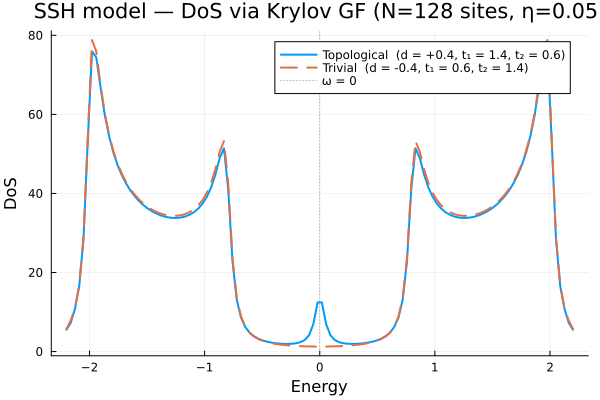

In [36]:
# Krylov GF parameters
η_ssh    = 0.05       # Lorentzian broadening
nsweeps  = 10
maxdim   = 50
cutoff   = 1e-7

ω_ssh = range(-2.2, 2.2; length=120)

dos_triv  = Float64[]
dos_top = Float64[]

for ω_p in ω_ssh
    G_triv  = TensorBinding.get_green_krylov(H_triv,  ω_p; η=η_ssh, nsweeps=nsweeps, maxdim=maxdim, cutoff=cutoff)
    G_top = TensorBinding.get_green_krylov(H_top, ω_p; η=η_ssh, nsweeps=nsweeps, maxdim=maxdim, cutoff=cutoff)
    push!(dos_top,  -imag(tr(G_top))  / π)
    push!(dos_triv, -imag(tr(G_triv)) / π)
end

plot(ω_ssh, dos_top;
     label  = "Topological  (d = +$(d_top), t₁ = $(t_ssh + d_top), t₂ = $(t_ssh - d_top))",
     lw=2, xlabel="Energy", ylabel="DoS",
     title  = "SSH model — DoS via Krylov GF (N=$(2^L_ssh) sites, η=$η_ssh)")
plot!(ω_ssh, dos_triv;
     label  = "Trivial  (d = $(d_triv), t₁ = $(t_ssh + d_triv), t₂ = $(t_ssh - d_triv))",
     lw=2, ls=:dash)
vline!([0.0]; ls=:dot, color=:gray, alpha=0.6, label="ω = 0")

---
## 5. QPI — 1D chain scattering wavevector map

A single on-site impurity scatters quasiparticles between time-reversed Fermi
points.  In 1D the backscattering wavevector $q = 2k_F(\omega)$ follows the
dispersion $\varepsilon(k) = -2t\cos(ka)$ exactly, so the QPI map
$|\delta\tilde{A}(q,\omega)|^2$ should trace two symmetric arcs in $(q,\omega)$
space that touch $q = \pi$ at $\omega = 0$ and fan out to $q \to 0, 2\pi$ at
the band edges.

A smooth disk window (via `sdf_interval` + logistic sigmoid, same machinery as
`mask_hamiltonian`) is applied to $\delta A(r,\omega)$ before the QFT to
suppress open-boundary ringing.

**Impurity MPO check:** before the main run a small $L=3$, $N=8$ system verifies
that `_impurity_mpo` places $V$ exactly at site $x_0$ and is zero elsewhere.

Impurity MPO check  (L=3, N=8, x0=4, V=0.1)
Diagonal entries   : [0.0, 0.0, 0.0, 0.1, 0.0, 0.0, 0.0, 0.0]
Expected           : all zeros except index 4 → 0.1
Max off-diagonal   : 0.0
Impurity MPO: OK

TBHamiltonian | L=8, N=256, scale=2.0, maxlinkdim=3 | geometry: 256 sites, 1D | no Tn cache
QPI: impurity at site 128 / 256,  V = 2.0,  Ncheb = 80
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -1.9974,  E_max = 2.8284
  center = 0.4155,  scale = 2.6542
QPI: online KPM clean…
  QPI clean 10/80  maxlinkdim=4
  QPI clean 20/80  maxlinkdim=4
  QPI clean 30/80  maxlinkdim=4
  QPI clean 40/80  maxlinkdim=4
  QPI clean 50/80  maxlinkdim=4
  QPI clean 60/80  maxlinkdim=4
  QPI clean 70/80  maxlinkdim=4
  QPI clean 80/80  maxlinkdim=4
QPI: online KPM impurity…
  QPI imp 10/80  maxlinkdim=12
  QPI imp 20/80  maxlinkdim=17
  QPI imp 30/80  maxlinkdim=25
  QPI imp 40/80  maxlinkdim=34
  QPI imp 50/80  maxlinkdim=44
  QPI imp 60/80  maxlinkdim=50
  QPI imp 70/80  maxlinkdim=52
  QPI imp 80/80

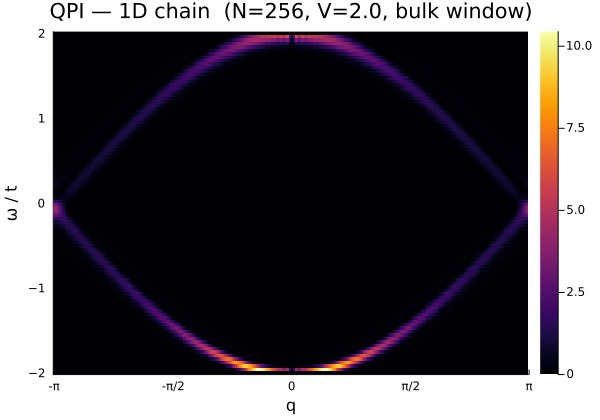

In [25]:
# ── Impurity MPO sanity check (L=3, N=8) ─────────────────────────────────────
# Build the impurity MPO directly and inspect its 8×8 dense matrix.
# Expected: V on the diagonal at row/col x0 (0-indexed), zeros everywhere else.
L_chk = 3;  x0_chk = 4;  V_chk = 0.1
H_chk = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_chk, scale=4.0)
imp_chk  = TensorBinding._impurity_mpo(x0_chk, L_chk, H_chk.sites, V_chk)
mat_chk  = TensorBinding.get_matrix(imp_chk, H_chk.sites)
diag_chk = real.(diag(mat_chk))
max_od   = maximum(abs.(mat_chk .- Diagonal(diag(mat_chk))))

println("Impurity MPO check  (L=$L_chk, N=$(2^L_chk), x0=$x0_chk, V=$V_chk)")
println("Diagonal entries   : ", round.(diag_chk; digits=8))
println("Expected           : all zeros except index $x0_chk → $V_chk")
println("Max off-diagonal   : ", max_od)
@assert abs(diag_chk[x0_chk] - V_chk) < 1e-10  "diagonal at x0 wrong"
@assert maximum(abs.(diag_chk[setdiff(1:2^L_chk, [x0_chk])])) < 1e-10 "unwanted diagonal leak"
@assert max_od < 1e-10                           "off-diagonal leak"
println("Impurity MPO: OK")

# ── 1D chain Hamiltonian ──────────────────────────────────────────────────────
L_fs = 8              # N = 64 sites
H_fs = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L_fs, bc = :periodic, scale=2.0)
println("\n", H_fs)

# ── QPI sweep ─────────────────────────────────────────────────────────────────
# ε(k) = -2t cos(2πk/N), bandwidth [-2, 2]. Stay 10% inside to avoid band edge.
Ncheb_fs = 80
ω_fs     = range(-2.0, 2.0; length=100)

qpi_fs = TensorBinding.get_qpi(H_fs, Ncheb_fs, ω_fs;
    V               = 2.0,
    window_fraction = 0.6,
    window_sigma    = 1.5,
    maxdim          = 60,
    cutoff          = 1e-6,
    verbose         = true)

# ── QPI heatmap: q vs ω ───────────────────────────────────────────────────────
# Circshift by N/2 so Γ (q=0) sits in the centre; LSB-first k → physical q = k·2π/N
N_fs     = H_fs.N
qpi_plot = circshift(qpi_fs, (0, N_fs ÷ 2)) .* N_fs
q_ax     = ((-(N_fs÷2)):(N_fs÷2 - 1)) ./ N_fs .* 2π    # [-π, π)

heatmap(q_ax, collect(ω_fs), qpi_plot;
    xlabel = "q",
    ylabel = "ω / t",
    title  = "QPI — 1D chain  (N=$N_fs, V=2.0, bulk window)",
    color  = :inferno,
    xticks = ([-π, -π/2, 0, π/2, π], ["-π", "-π/2", "0", "π/2", "π"]),
    size   = (600, 420))

---
## 6. QPI — 2D square lattice

The square lattice dispersion $\varepsilon(\mathbf{k}) = -2t(\cos k_x + \cos k_y)$
has bandwidth $[-4t,\, 4t]$.  At half-filling ($\omega = 0$) the Fermi surface
is a diamond rotated 45°, with perfect nesting along $\mathbf{q} = (\pi,0)$,
$(0,\pi)$, and $(\pi,\pi)$.

The impurity response
$\delta A(\mathbf{r},\omega) = A_\mathrm{imp}(\mathbf{r},\omega) - A_\mathrm{clean}(\mathbf{r},\omega)$
is Fourier-transformed with the forward QFT MPO and the QPI pattern
$|\delta\tilde{A}(\mathbf{q},\omega)|^2$ is displayed for representative energies.
A circular apodization window (`window_fraction=0.7`) suppresses open-boundary
ringing before the transform.

TBHamiltonian | L=10, N=1024, scale=4.4, maxlinkdim=4 | geometry: 1024 sites, 2D | no Tn cache
QPI: impurity at site 496 / 1024,  V=2.0,  mode=:delta,  Ncheb=100
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -3.9784,  E_max = 4.0575
  center = 0.0395,  scale = 4.4197
QPI: online KPM clean…
  QPI clean 10/100  maxlinkdim=30
  QPI clean 20/100  maxlinkdim=40
  QPI clean 30/100  maxlinkdim=50
  QPI clean 40/100  maxlinkdim=54
  QPI clean 50/100  maxlinkdim=62
  QPI clean 60/100  maxlinkdim=65
  QPI clean 70/100  maxlinkdim=67
  QPI clean 80/100  maxlinkdim=67
  QPI clean 90/100  maxlinkdim=70
  QPI clean 100/100  maxlinkdim=76
QPI: online KPM impurity…
  QPI imp 10/100  maxlinkdim=63
  QPI imp 20/100  maxlinkdim=100
  QPI imp 30/100  maxlinkdim=100
  QPI imp 40/100  maxlinkdim=100
  QPI imp 50/100  maxlinkdim=100
  QPI imp 60/100  maxlinkdim=100
  QPI imp 70/100  maxlinkdim=100
  QPI imp 80/100  maxlinkdim=100
  QPI imp 90/100  maxlinkdim=100
  QPI imp 100/100  maxlinkdim=100
QPI

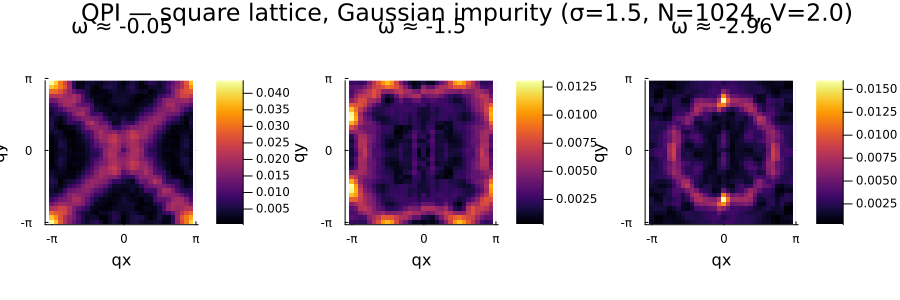

In [3]:
# ── Square lattice Hamiltonian ────────────────────────────────────────────────
Lx_sq    = 5;  Ly_sq = 5          # 32×32 = 1024 sites
L_sq     = Lx_sq + Ly_sq
t_sq     = 1.0
scale_sq = 4.0 * t_sq * 1.1       # analytic bandwidth × 10 % buffer

H_sq = TensorBinding.get_Hamiltonian("square_2d", t_sq;
           L=L_sq, Lx=Lx_sq, scale=scale_sq)
println(H_sq)

# ── QPI sweep (Gaussian impurity mode) ───────────────────────────────────────
# A smooth Gaussian V·exp(-|r-r₀|²/2σ²) is built via add_onsite! rather than
# the exact rank-1 projector.  The smooth potential is compressible by QTCI and
# yields a much lower-BD impurity MPO, keeping the KPM recursion manageable.
Ncheb_sq = 100
ω_sq     = range(-3.6, 3.6; length=80)

qpi_sq = TensorBinding.get_qpi(H_sq, Ncheb_sq, ω_sq;
    V               = 2.0,
    window_fraction = 0.8,
    window_sigma    = 1.5,
    maxdim          = 100,
    cutoff          = 1e-6,
    verbose         = true)

# ── Reshape and plot for representative energies ──────────────────────────────
# qpi_sq[iω, k+1]: k = kx + Nx*ky  (x varies fast, LSB-first)
# reshape(row, Nx, Ny)' → matrix indexed [qy, qx] for heatmap
Nx_sq = 2^Lx_sq;  Ny_sq = 2^Ly_sq
qx_ax = ((-(Nx_sq÷2)):(Nx_sq÷2 - 1)) ./ Nx_sq .* 2π
qy_ax = ((-(Ny_sq÷2)):(Ny_sq÷2 - 1)) ./ Ny_sq .* 2π

ω_targets = [0.0, -1.5, -3.0]     # Fermi level, van Hove singularity, near band edge
ω_arr     = collect(ω_sq)

ps = map(ω_targets) do ω_p
    iω     = argmin(abs.(ω_arr .- ω_p))
    qpi_2d = reshape(qpi_sq[iω, :], Nx_sq, Ny_sq)'
    qpi_c  = circshift(qpi_2d, (Ny_sq÷2, Nx_sq÷2))
    heatmap(qx_ax, qy_ax, sqrt.(qpi_c);
        xlabel="qx", ylabel="qy",
        title="ω ≈ $(round(ω_arr[iω]; digits=2))",
        color=:inferno, aspect_ratio=1,
        xticks=([-π, 0, π], ["-π", "0", "π"]),
        yticks=([-π, 0, π], ["-π", "0", "π"]))
end

plot(ps...;
    layout     = (1, length(ω_targets)),
    size       = (300 * length(ω_targets), 300),
    plot_title = "QPI — square lattice, Gaussian impurity (σ=1.5, N=$(H_sq.N), V=2.0)")